# 3. Αξιολόγηση Μοντέλου, Βελτιστοποίηση Υπερπαραμέτρων και Ερμηνευσιμότητα  
## (Model Evaluation, Hyperparameter Tuning & Interpretability)

Το παρόν notebook αποτελεί το τρίτο στάδιο της εμπειρικής ανάλυσης για την αγορά μεταχειρισμένων αυτοκινήτων στην Αττική κατά την περίοδο 2021–2026.

Μετά την ολοκλήρωση του **Notebook 1** (καθαρισμός δεδομένων και EDA) και του **Notebook 2** (μοντελοποίηση και πρόβλεψη τιμής), η παρούσα ενότητα εστιάζει στην **πιο αναλυτική αξιολόγηση των καλύτερων μοντέλων**, στη **βελτιστοποίηση υπερπαραμέτρων**, καθώς και στην **ερμηνεία του τελικού μοντέλου**.

Ειδικότερα, το notebook αυτό επιδιώκει:

- τη βελτιστοποίηση των μοντέλων **Random Forest** και **XGBoost**
- τη σύγκριση **tuned** και **untuned** εκδόσεων
- την εκτέλεση αναλυτικού **error analysis**
- την εξέταση της συμπεριφοράς των **residuals**
- την αξιολόγηση σφάλματος ανά **fuel type**, **manufacturer**, **registration year** και **price segment**
- την εφαρμογή **SHAP** για την ερμηνεία της συνεισφοράς των μεταβλητών
- και, τέλος, την τεκμηριωμένη επιλογή του μοντέλου που θα παρουσιαστεί στην πτυχιακή εργασία

## Μεθοδολογικό Πλαίσιο Αξιολόγησης

Η ροή της ανάλυσης ακολουθεί τα εξής στάδια:

1. **Φόρτωση** του `ml_ready_car_data.csv` και των εξαγόμενων αποτελεσμάτων του Notebook 2  
2. **Περιορισμός** στο used-only subset (`Κατάσταση = Μεταχειρισμένο`)  
3. **Επαναδημιουργία** του ίδιου preprocessing pipeline για λόγους συνέπειας και αναπαραγωγιμότητας  
4. **Ορισμός** untuned baseline εκδόσεων των δύο καλύτερων tree-based μοντέλων  
5. **Hyperparameter tuning** με `RandomizedSearchCV` και 3-fold cross-validation  
6. **Αξιολόγηση** tuned και untuned μοντέλων στο ίδιο test set  
7. **Δημιουργία** αναλυτικού πίνακα προβλέψεων και residuals  
8. **Ομαδοποιημένη ανάλυση σφάλματος** ανά βασικά market segments  
9. **SHAP interpretability** για το τελικό μοντέλο  
10. **Εξαγωγή** όλων των βασικών αποτελεσμάτων στο `data/processed/`

Η συγκεκριμένη δομή διατηρεί την αναπαραγωγιμότητα της μελέτης και επιτρέπει την άμεση ενσωμάτωση των αποτελεσμάτων στη συγγραφή της πτυχιακής εργασίας.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

c:\Users\athin\Desktop\Car-Market-Analysis-Attica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# ΒΑΣΙΚΕΣ ΡΥΘΜΙΣΕΙΣ ΚΑΙ HELPER FUNCTIONS
# ============================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 3
N_ITER_RF = 12
N_ITER_XGB = 12
SHAP_SAMPLE_SIZE = 400


def resolve_data_path(filename: str) -> Path:
    """
    Εντοπίζει το αρχείο δεδομένων είτε μέσα στο project
    είτε στο προσωρινό περιβάλλον εκτέλεσης.
    """
    candidate_paths = [
        Path.cwd() / "data" / "processed" / filename,
        Path.cwd().parent / "data" / "processed" / filename,
        Path("/mnt/data") / filename,
        Path("/mnt/data") / "data" / "processed" / filename,
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    raise FileNotFoundError(f"Δεν βρέθηκε το αρχείο: {filename}")


def resolve_output_dir() -> Path:
    """
    Επιστρέφει τον φάκελο αποθήκευσης αποτελεσμάτων.
    """
    candidate_dirs = [
        Path.cwd() / "data" / "processed",
        Path.cwd().parent / "data" / "processed",
        Path("/mnt/data"),
    ]

    for directory in candidate_dirs:
        if directory.exists() or "data/processed" in str(directory):
            directory.mkdir(parents=True, exist_ok=True)
            return directory

    raise FileNotFoundError("Δεν ήταν δυνατός ο εντοπισμός φακέλου εξόδου.")


def safe_mape(y_true, y_pred):
    """
    Υπολογισμός MAPE με προστασία έναντι διαίρεσης με το μηδέν.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    """
    Βασικές μετρικές παλινδρόμησης.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def error_metrics_extended(y_true, y_pred):
    """
    Εμπλουτισμένες μετρικές αξιολόγησης για αναλυτικό error analysis.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_true - y_pred

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "Bias": residuals.mean(),
        "MAPE_%": safe_mape(y_true, y_pred),
    }


def make_price_segment(price_series):
    """
    Δημιουργία ερμηνεύσιμων price segments για την ανάλυση σφάλματος.
    """
    bins = [-np.inf, 10000, 20000, 35000, 60000, np.inf]
    labels = ["<=10k", "10k–20k", "20k–35k", "35k–60k", ">60k"]

    return pd.cut(price_series, bins=bins, labels=labels, ordered=True)


def metrics_by_group(df_input, group_col, min_count=20):
    """
    Υπολογισμός μετρικών ανά ομάδα.
    """
    rows = []

    grouped = df_input.dropna(subset=[group_col]).groupby(group_col, observed=False)

    for group_value, group_df in grouped:
        if len(group_df) < min_count:
            continue

        metrics = error_metrics_extended(
            group_df["Actual_Price"],
            group_df["Predicted_Price"]
        )

        rows.append({
            group_col: group_value,
            "Count": len(group_df),
            "Mean_Actual_Price": group_df["Actual_Price"].mean(),
            "Mean_Predicted_Price": group_df["Predicted_Price"].mean(),
            **metrics
        })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    if str(df_input[group_col].dtype) == "category":
        return result.sort_values(by=group_col).reset_index(drop=True)

    return result.reset_index(drop=True)


def summarize_search(search_obj, model_name):
    """
    Συνοπτικός πίνακας των καλύτερων CV αποτελεσμάτων από RandomizedSearchCV.
    """
    cv_results = pd.DataFrame(search_obj.cv_results_).copy()
    cv_results["CV_RMSE"] = -cv_results["mean_test_score"]

    top_results = (
        cv_results
        .sort_values(by="rank_test_score")
        [["rank_test_score", "CV_RMSE", "std_test_score", "params"]]
        .head(5)
        .reset_index(drop=True)
    )

    top_results.insert(0, "Model", model_name)
    return top_results


def get_original_feature_name(transformed_feature_name, numeric_features, categorical_features):
    """
    Αντιστοιχίζει τα transformed feature names του pipeline
    πίσω στις αρχικές μεταβλητές.
    """
    clean_name = transformed_feature_name.split("__", 1)[-1]

    if clean_name in numeric_features:
        return clean_name

    for col in categorical_features:
        if clean_name.startswith(f"{col}_"):
            return col

    return clean_name

## Φόρτωση Δεδομένων και Αποτελεσμάτων Προηγούμενου Σταδίου

Στο σημείο αυτό φορτώνονται:

- το βασικό modeling dataset `ml_ready_car_data.csv`
- ο πίνακας αποτελεσμάτων του Notebook 2 (`model_comparison_results.csv`)
- και οι προβλέψεις του προηγούμενου καλύτερου μοντέλου (`best_model_test_predictions.csv`)

Η ταυτόχρονη χρήση των παραπάνω αρχείων επιτρέπει:

- τη **συνέχεια** μεταξύ Notebook 2 και Notebook 3
- τον **έλεγχο συνέπειας** των προηγούμενων αποτελεσμάτων
- και τη **συγκριτική αξιολόγηση** των tuned μοντέλων με την προηγούμενη untuned baseline κατάσταση

In [3]:
# ============================================================
# ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΚΑΙ OUTPUTS NOTEBOOK 2
# ============================================================

ml_data_path = resolve_data_path("ml_ready_car_data.csv")
model_results_path = resolve_data_path("model_comparison_results.csv")
prev_predictions_path = resolve_data_path("best_model_test_predictions.csv")

df = pd.read_csv(ml_data_path)
prev_results_df = pd.read_csv(model_results_path)
prev_best_predictions_df = pd.read_csv(prev_predictions_path)

print("Data path:", ml_data_path)
print("Previous model results path:", model_results_path)
print("Previous predictions path:", prev_predictions_path)

print("\nShape main dataset:", df.shape)
print("Shape previous results:", prev_results_df.shape)
print("Shape previous predictions:", prev_best_predictions_df.shape)

print("\nΣτήλες dataset:")
print(df.columns.tolist())

print("\nΠρώτες 5 γραμμές του modeling dataset:")
display(df.head())

print("\nΑποτελέσματα Notebook 2:")
display(prev_results_df)

print("\nΠρώτες 5 γραμμές προηγούμενων προβλέψεων:")
display(prev_best_predictions_df.head())

Data path: c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\ml_ready_car_data.csv
Previous model results path: c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\model_comparison_results.csv
Previous predictions path: c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\best_model_test_predictions.csv

Shape main dataset: (8933, 12)
Shape previous results: (5, 4)
Shape previous predictions: (1660, 3)

Στήλες dataset:
['Κατασκευαστής', 'Τύπος', 'Εγγραφή', 'Ηλικία', 'Καύσιμο', 'Μετάδοση', 'Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα', 'Κατάσταση', 'Περιοχή', 'Τιμή']

Πρώτες 5 γραμμές του modeling dataset:


,Κατασκευαστής,Τύπος,Εγγραφή,Ηλικία,Καύσιμο,Μετάδοση,Κυβικά,Ιπποδύναμη,Χιλιόμετρα,Κατάσταση,Περιοχή,Τιμή
0,Audi,Q3,"2,025.00",1.00,Βενζίνη,Αυτόματο,"1,500.00",150.00,"10,500.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14561,"34,900.00"
1,Toyota,Yaris Cross,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,500.00",116.00,"10,018.00",Μεταχειρισμένο,ΝΕΑ ΙΩΝΙΑ 14235,"25,990.00"
2,Peugeot,2008,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,200.00",145.00,"3,000.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14562,"26,500.00"
3,Peugeot,2008,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,200.00",145.00,"2,900.00",Μεταχειρισμένο,ΝΕΑ ΕΡΥΘΡΑΙA 14671,"26,500.00"
4,Beev,ΒEEV-6,"2,025.00",1.00,Ηλεκτρικό,Αυτόματο,NaN,4.00,0.00,Καινούργιο,ΓΛΥΚΑ ΝΕΡΑ 15354,"10,900.00"



Αποτελέσματα Notebook 2:


,Μοντέλο,MAE,RMSE,R2
0,XGBoost,"4,089.66","7,587.25",0.94
1,RandomForest,"3,855.42","8,159.86",0.93
2,Ridge,"5,670.67","9,988.70",0.90
3,LinearRegression,"5,301.68","10,312.95",0.89
4,DummyRegressor,"16,831.92","33,345.89",-0.13



Πρώτες 5 γραμμές προηγούμενων προβλέψεων:


,Actual_Price,Predicted_Price,Residual
0,"90,000.00","60,678.31","29,321.70"
1,"11,900.00","13,393.32","-1,493.32"
2,"22,500.00","20,594.51","1,905.49"
3,"25,550.00","28,773.64","-3,223.64"
4,"12,900.00","12,168.12",731.88


## Επιλογή Used-Only Υποσυνόλου και Διαχωρισμός Train/Test

Όπως και στο προηγούμενο notebook, η κύρια ανάλυση περιορίζεται αποκλειστικά στο υποσύνολο των **μεταχειρισμένων οχημάτων**, ώστε το τελικό μοντέλο να αντανακλά με συνέπεια το κύριο ερευνητικό αντικείμενο της μελέτης.

Για λόγους συγκρισιμότητας με το Notebook 2:

- χρησιμοποιείται το ίδιο **used-only subset**
- διατηρείται η ίδια λογική επιλογής μεταβλητών
- και εφαρμόζεται ο ίδιος **τυχαίος διαχωρισμός train/test** με `random_state = 42`

In [4]:
# ============================================================
# USED-ONLY SUBSET ΚΑΙ TRAIN/TEST SPLIT
# ============================================================

print("Κατανομή μεταβλητής 'Κατάσταση':")
display(
    df["Κατάσταση"]
    .value_counts(dropna=False)
    .rename_axis("Κατάσταση")
    .reset_index(name="Πλήθος")
)

# Κρατάμε μόνο μεταχειρισμένα οχήματα
df_model = df[df["Κατάσταση"] == "Μεταχειρισμένο"].copy()

print("\nShape used-only dataset:", df_model.shape)

# Ορισμός predictors και target
features_to_drop = ["Τιμή", "Κατάσταση", "Εγγραφή"]
X = df_model.drop(columns=features_to_drop)
y = df_model["Τιμή"].copy()

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget variable:")
print("Τιμή")

# Διαχωρισμός train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("\nShapes μετά το split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nΠεριγραφικά στατιστικά της τιμής (used-only subset):")
display(y.describe().to_frame(name="Τιμή"))

Κατανομή μεταβλητής 'Κατάσταση':


,Κατάσταση,Πλήθος
0,Μεταχειρισμένο,8296
1,Καινούργιο,623
2,Leasing,14



Shape used-only dataset: (8296, 12)

Predictor columns:
['Κατασκευαστής', 'Τύπος', 'Ηλικία', 'Καύσιμο', 'Μετάδοση', 'Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα', 'Περιοχή']

Target variable:
Τιμή

Shapes μετά το split:
X_train: (6636, 9)
X_test : (1660, 9)
y_train: (6636,)
y_test : (1660,)

Περιγραφικά στατιστικά της τιμής (used-only subset):


,Τιμή
count,"8,296.00"
mean,"33,280.20"
std,"34,021.78"
min,"2,000.00"
25%,"16,700.00"
50%,"22,000.00"
75%,"35,000.00"
max,"550,000.00"


## Preprocessing Pipeline και Untuned Baseline Μοντέλα

Για να διατηρηθεί η μεθοδολογική συνέπεια με το Notebook 2, χρησιμοποιείται το ίδιο preprocessing pipeline:

- **median imputation + scaling** για τις αριθμητικές μεταβλητές
- **most frequent imputation + one-hot encoding** για τις κατηγορικές μεταβλητές

Στη συνέχεια ορίζονται δύο untuned baseline μοντέλα:

- **RandomForestRegressor**
- **XGBRegressor**

με παραμέτρους εναρμονισμένες με την προηγούμενη μοντελοποίηση, ώστε η μετέπειτα σύγκριση με τις tuned εκδόσεις να είναι άμεσα ερμηνεύσιμη.

In [5]:
# ============================================================
# PREPROCESSING ΚΑΙ UNTUNED ΜΟΝΤΕΛΑ
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Αριθμητικές μεταβλητές:")
print(numeric_features)

print("\nΚατηγορικές μεταβλητές:")
print(categorical_features)

# Συμβατότητα μεταξύ διαφορετικών εκδόσεων scikit-learn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Untuned baseline μοντέλα
untuned_models = {
    "RandomForest_untuned": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost_untuned": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
}

print("\nΤα untuned baseline μοντέλα ορίστηκαν επιτυχώς.")
print(list(untuned_models.keys()))

Αριθμητικές μεταβλητές:
['Ηλικία', 'Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα']

Κατηγορικές μεταβλητές:
['Κατασκευαστής', 'Τύπος', 'Καύσιμο', 'Μετάδοση', 'Περιοχή']

Τα untuned baseline μοντέλα ορίστηκαν επιτυχώς.
['RandomForest_untuned', 'XGBoost_untuned']


## Αναφορά στα Αποτελέσματα του Notebook 2

Πριν από το tuning, παρουσιάζονται συνοπτικά τα αποτελέσματα του προηγούμενου notebook.

Ο στόχος του βήματος αυτού είναι διττός:

1. να επιβεβαιωθεί ότι το **XGBoost** αποτέλεσε το προηγούμενο καλύτερο μοντέλο
2. να υπάρχει σαφές **σημείο αναφοράς (benchmark)** για την αξιολόγηση της επίδρασης του hyperparameter tuning

In [6]:
# ============================================================
# ΣΥΝΟΨΗ ΠΡΟΗΓΟΥΜΕΝΩΝ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================

prev_results_sorted = prev_results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

previous_best_model_name = prev_results_sorted.iloc[0]["Μοντέλο"]
previous_best_metrics = regression_metrics(
    prev_best_predictions_df["Actual_Price"],
    prev_best_predictions_df["Predicted_Price"]
)

print("Καλύτερο μοντέλο στο Notebook 2:", previous_best_model_name)

print("\nΜετρικές από το exported αρχείο προβλέψεων του προηγούμενου καλύτερου μοντέλου:")
display(
    pd.DataFrame([previous_best_metrics])
)

print("\nΤαξινομημένα αποτελέσματα Notebook 2:")
display(prev_results_sorted)

Καλύτερο μοντέλο στο Notebook 2: XGBoost

Μετρικές από το exported αρχείο προβλέψεων του προηγούμενου καλύτερου μοντέλου:


,MAE,RMSE,R2
0,"4,089.66","7,587.25",0.94



Ταξινομημένα αποτελέσματα Notebook 2:


,Μοντέλο,MAE,RMSE,R2
0,XGBoost,"4,089.66","7,587.25",0.94
1,RandomForest,"3,855.42","8,159.86",0.93
2,Ridge,"5,670.67","9,988.70",0.90
3,LinearRegression,"5,301.68","10,312.95",0.89
4,DummyRegressor,"16,831.92","33,345.89",-0.13


## Hyperparameter Tuning για RandomForest και XGBoost

Στο στάδιο αυτό εφαρμόζεται **RandomizedSearchCV** για τα δύο καλύτερα tree-based μοντέλα.

Η επιλογή του `RandomizedSearchCV` προτιμάται έναντι ενός πλήρους `GridSearchCV`, διότι:

- επιτρέπει **λογικό και όχι υπερβολικό** εύρος αναζήτησης
- είναι πιο **υπολογιστικά αποδοτική**
- και παραμένει κατάλληλη για ακαδημαϊκή τεκμηρίωση, όταν συνοδεύεται από σαφή ορισμό του search space

Ως κύριο κριτήριο βελτιστοποίησης χρησιμοποιείται το **RMSE** μέσω 3-fold cross-validation.

In [7]:
# ============================================================
# ΟΡΙΣΜΟΣ SEARCH SPACES ΚΑΙ RANDOMIZED SEARCH OBJECTS
# ============================================================

# Σημείωση:
# Κατά το tuning χρησιμοποιούμε n_jobs=1 μέσα στο estimator,
# ώστε να αποφεύγεται υπερβολικό nested parallelism όταν το
# RandomizedSearchCV τρέχει με n_jobs=-1.

rf_search_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1
)

xgb_search_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbosity=0
)

rf_param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

xgb_param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [4, 5, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.07, 0.10],
    "model__subsample": [0.70, 0.80, 0.90, 1.00],
    "model__colsample_bytree": [0.70, 0.80, 0.90, 1.00],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha": [0.00, 0.10, 0.50],
    "model__reg_lambda": [1.0, 1.5, 2.0]
}

rf_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", rf_search_model)
    ]),
    param_distributions=rf_param_distributions,
    n_iter=N_ITER_RF,
    scoring="neg_root_mean_squared_error",
    cv=CV_FOLDS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

xgb_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_search_model)
    ]),
    param_distributions=xgb_param_distributions,
    n_iter=N_ITER_XGB,
    scoring="neg_root_mean_squared_error",
    cv=CV_FOLDS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("RandomForest tuning iterations:", N_ITER_RF)
print("XGBoost tuning iterations:", N_ITER_XGB)
print("CV folds:", CV_FOLDS)

RandomForest tuning iterations: 12
XGBoost tuning iterations: 12
CV folds: 3


In [8]:
# ============================================================
# ΕΚΤΕΛΕΣΗ HYPERPARAMETER TUNING
# ============================================================

print("Ξεκινά το tuning για το RandomForest...")
rf_search.fit(X_train, y_train)

print("\nΞεκινά το tuning για το XGBoost...")
xgb_search.fit(X_train, y_train)

print("\nΤο hyperparameter tuning ολοκληρώθηκε.")

Ξεκινά το tuning για το RandomForest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Ξεκινά το tuning για το XGBoost...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Το hyperparameter tuning ολοκληρώθηκε.


In [9]:
# ============================================================
# ΣΥΝΟΨΗ ΒΕΛΤΙΣΤΩΝ ΠΑΡΑΜΕΤΡΩΝ ΚΑΙ CV ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================

search_summary_rows = []
cv_top_results = {}

search_objects = {
    "RandomForest_tuned": rf_search,
    "XGBoost_tuned": xgb_search
}

for model_name, search_obj in search_objects.items():
    search_summary_rows.append({
        "Model": model_name,
        "Best_CV_RMSE": -search_obj.best_score_,
        "Best_Params": search_obj.best_params_
    })

    cv_top_results[model_name] = summarize_search(search_obj, model_name)

search_summary_df = pd.DataFrame(search_summary_rows).sort_values(by="Best_CV_RMSE", ascending=True).reset_index(drop=True)

print("Σύνοψη tuning αποτελεσμάτων:")
display(search_summary_df)

print("\nTop 5 CV αποτελέσματα για το RandomForest:")
display(cv_top_results["RandomForest_tuned"])

print("\nTop 5 CV αποτελέσματα για το XGBoost:")
display(cv_top_results["XGBoost_tuned"])

Σύνοψη tuning αποτελεσμάτων:


,Model,Best_CV_RMSE,Best_Params
0,XGBoost_tuned,"9,908.44","{'model__subsample': 0.9, 'model__reg_lambda':..."
1,RandomForest_tuned,"10,443.50","{'model__n_estimators': 200, 'model__min_sampl..."



Top 5 CV αποτελέσματα για το RandomForest:


,Model,rank_test_score,CV_RMSE,std_test_score,params
0,RandomForest_tuned,1,"10,443.50","1,123.58","{'model__n_estimators': 200, 'model__min_sampl..."
1,RandomForest_tuned,2,"10,660.96",949.17,"{'model__n_estimators': 500, 'model__min_sampl..."
2,RandomForest_tuned,3,"10,963.47",921.66,"{'model__n_estimators': 200, 'model__min_sampl..."
3,RandomForest_tuned,4,"13,485.78","1,193.77","{'model__n_estimators': 500, 'model__min_sampl..."
4,RandomForest_tuned,5,"15,042.97","1,430.28","{'model__n_estimators': 200, 'model__min_sampl..."



Top 5 CV αποτελέσματα για το XGBoost:


,Model,rank_test_score,CV_RMSE,std_test_score,params
0,XGBoost_tuned,1,"9,908.44",556.81,"{'model__subsample': 0.9, 'model__reg_lambda':..."
1,XGBoost_tuned,2,"10,051.71",873.67,"{'model__subsample': 0.7, 'model__reg_lambda':..."
2,XGBoost_tuned,3,"10,182.36",887.94,"{'model__subsample': 0.8, 'model__reg_lambda':..."
3,XGBoost_tuned,4,"10,430.13",495.60,"{'model__subsample': 1.0, 'model__reg_lambda':..."
4,XGBoost_tuned,5,"10,544.34",465.97,"{'model__subsample': 0.9, 'model__reg_lambda':..."


## Αξιολόγηση Tuned και Untuned Μοντέλων στο Test Set

Αφού ολοκληρωθεί η διαδικασία tuning, αξιολογούνται στο ίδιο test set οι εξής τέσσερις υποψήφιες εκδοχές:

- `RandomForest_untuned`
- `RandomForest_tuned`
- `XGBoost_untuned`
- `XGBoost_tuned`

Με τον τρόπο αυτό καθίσταται δυνατή:

- η άμεση σύγκριση της επίδρασης του tuning
- η τελική επιλογή του καλύτερου μοντέλου
- και η αποτίμηση του κατά πόσο η cross-validated βελτιστοποίηση μεταφράζεται σε καλύτερη απόδοση και στο hold-out test set

In [10]:
# ============================================================
# TEST SET EVALUATION: TUNED VS UNTUNED
# ============================================================

trained_pipelines = {}
evaluation_rows = []

# ----------------------------------------
# 1. Untuned models
# ----------------------------------------
for model_name, model in untuned_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = error_metrics_extended(y_test, y_pred)

    trained_pipelines[model_name] = pipeline

    evaluation_rows.append({
        "Model": model_name,
        "Model_Family": model_name.split("_")[0],
        "Tuning_Status": "Untuned",
        "CV_Best_RMSE": np.nan,
        **metrics
    })

# ----------------------------------------
# 2. Tuned models
# ----------------------------------------
tuned_estimators = {
    "RandomForest_tuned": rf_search.best_estimator_,
    "XGBoost_tuned": xgb_search.best_estimator_
}

for model_name, pipeline in tuned_estimators.items():
    y_pred = pipeline.predict(X_test)

    metrics = error_metrics_extended(y_test, y_pred)

    trained_pipelines[model_name] = pipeline

    search_obj = rf_search if model_name == "RandomForest_tuned" else xgb_search

    evaluation_rows.append({
        "Model": model_name,
        "Model_Family": model_name.split("_")[0],
        "Tuning_Status": "Tuned",
        "CV_Best_RMSE": -search_obj.best_score_,
        **metrics
    })

evaluation_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values(by="RMSE", ascending=True)
    .reset_index(drop=True)
)

print("Συγκριτικά αποτελέσματα test set:")
display(evaluation_df)

# ----------------------------------------
# 3. Άμεση σύγκριση tuned vs untuned ανά οικογένεια μοντέλων
# ----------------------------------------
comparison_rows = []

for family in ["RandomForest", "XGBoost"]:
    untuned_row = evaluation_df[
        (evaluation_df["Model_Family"] == family) &
        (evaluation_df["Tuning_Status"] == "Untuned")
    ].iloc[0]

    tuned_row = evaluation_df[
        (evaluation_df["Model_Family"] == family) &
        (evaluation_df["Tuning_Status"] == "Tuned")
    ].iloc[0]

    comparison_rows.append({
        "Model_Family": family,
        "Untuned_RMSE": untuned_row["RMSE"],
        "Tuned_RMSE": tuned_row["RMSE"],
        "ΔRMSE_(Tuned-Untuned)": tuned_row["RMSE"] - untuned_row["RMSE"],
        "RMSE_Improvement_%": ((untuned_row["RMSE"] - tuned_row["RMSE"]) / untuned_row["RMSE"]) * 100,
        "Untuned_MAE": untuned_row["MAE"],
        "Tuned_MAE": tuned_row["MAE"],
        "ΔMAE_(Tuned-Untuned)": tuned_row["MAE"] - untuned_row["MAE"],
        "MAE_Improvement_%": ((untuned_row["MAE"] - tuned_row["MAE"]) / untuned_row["MAE"]) * 100
    })

tuned_vs_untuned_df = pd.DataFrame(comparison_rows)

print("\nΣύγκριση tuned vs untuned ανά model family:")
display(tuned_vs_untuned_df)

Συγκριτικά αποτελέσματα test set:


,Model,Model_Family,Tuning_Status,CV_Best_RMSE,MAE,RMSE,R2,MedAE,Bias,MAPE_%
0,XGBoost_untuned,XGBoost,Untuned,NaN,"4,089.66","7,587.25",0.94,"2,163.86",-192.68,12.42
1,XGBoost_tuned,XGBoost,Tuned,"9,908.44","3,832.86","7,700.57",0.94,"1,921.15",-240.64,11.08
2,RandomForest_untuned,RandomForest,Untuned,NaN,"3,855.42","8,159.86",0.93,"1,631.77",-140.25,10.60
3,RandomForest_tuned,RandomForest,Tuned,"10,443.50","3,832.15","8,202.31",0.93,"1,533.38",19.16,10.49



Σύγκριση tuned vs untuned ανά model family:


,Model_Family,Untuned_RMSE,Tuned_RMSE,ΔRMSE_(Tuned-Untuned),RMSE_Improvement_%,Untuned_MAE,Tuned_MAE,ΔMAE_(Tuned-Untuned),MAE_Improvement_%
0,RandomForest,"8,159.86","8,202.31",42.45,-0.52,"3,855.42","3,832.15",-23.26,0.60
1,XGBoost,"7,587.25","7,700.57",113.32,-1.49,"4,089.66","3,832.86",-256.79,6.28


## Τελική Επιλογή Μοντέλου και Δημιουργία Αναλυτικού Πίνακα Προβλέψεων

Το τελικό μοντέλο επιλέγεται με κύριο κριτήριο το **χαμηλότερο RMSE στο test set**, ενώ συνεκτιμώνται και τα **MAE**, **R²**, καθώς και η γενικότερη σταθερότητα της συμπεριφοράς του.

Στη συνέχεια δημιουργείται ένας αναλυτικός πίνακας προβλέψεων, ο οποίος περιλαμβάνει:

- πραγματική τιμή
- προβλεπόμενη τιμή
- residual
- absolute error
- percentage error
- βασικά market descriptors για περαιτέρω ομαδοποιημένη ανάλυση

In [11]:
# ============================================================
# ΤΕΛΙΚΗ ΕΠΙΛΟΓΗ ΜΟΝΤΕΛΟΥ ΚΑΙ PREDICTION TABLE
# ============================================================

final_model_name = evaluation_df.iloc[0]["Model"]
final_pipeline = trained_pipelines[final_model_name]
final_y_pred = final_pipeline.predict(X_test)

print("Τελικό επιλεγμένο μοντέλο:", final_model_name)
display(evaluation_df.head(4))

# Metadata για περαιτέρω αναλύσεις
test_metadata = df_model.loc[
    X_test.index,
    ["Κατασκευαστής", "Τύπος", "Εγγραφή", "Καύσιμο", "Μετάδοση", "Περιοχή", "Ηλικία", "Κυβικά", "Ιπποδύναμη", "Χιλιόμετρα"]
].copy()

final_predictions_df = test_metadata.copy()
final_predictions_df["Actual_Price"] = y_test
final_predictions_df["Predicted_Price"] = pd.Series(final_y_pred, index=X_test.index)
final_predictions_df["Residual"] = final_predictions_df["Actual_Price"] - final_predictions_df["Predicted_Price"]
final_predictions_df["Absolute_Error"] = final_predictions_df["Residual"].abs()
final_predictions_df["Squared_Error"] = final_predictions_df["Residual"] ** 2
final_predictions_df["Absolute_Percentage_Error_%"] = np.where(
    final_predictions_df["Actual_Price"] != 0,
    (final_predictions_df["Absolute_Error"] / final_predictions_df["Actual_Price"]) * 100,
    np.nan
)
final_predictions_df["Residual_Sign"] = np.where(
    final_predictions_df["Residual"] >= 0,
    "Υποεκτίμηση μοντέλου",
    "Υπερεκτίμηση μοντέλου"
)
final_predictions_df["Price_Segment"] = make_price_segment(final_predictions_df["Actual_Price"])
final_predictions_df["Εγγραφή"] = final_predictions_df["Εγγραφή"].astype("Int64")

print("Πίνακας τελικών προβλέψεων:")
display(final_predictions_df.head(10))

Τελικό επιλεγμένο μοντέλο: XGBoost_untuned


,Model,Model_Family,Tuning_Status,CV_Best_RMSE,MAE,RMSE,R2,MedAE,Bias,MAPE_%
0,XGBoost_untuned,XGBoost,Untuned,NaN,"4,089.66","7,587.25",0.94,"2,163.86",-192.68,12.42
1,XGBoost_tuned,XGBoost,Tuned,"9,908.44","3,832.86","7,700.57",0.94,"1,921.15",-240.64,11.08
2,RandomForest_untuned,RandomForest,Untuned,NaN,"3,855.42","8,159.86",0.93,"1,631.77",-140.25,10.60
3,RandomForest_tuned,RandomForest,Tuned,"10,443.50","3,832.15","8,202.31",0.93,"1,533.38",19.16,10.49


Πίνακας τελικών προβλέψεων:


,Κατασκευαστής,Τύπος,Εγγραφή,Καύσιμο,Μετάδοση,Περιοχή,Ηλικία,Κυβικά,Ιπποδύναμη,Χιλιόμετρα,Actual_Price,Predicted_Price,Residual,Absolute_Error,Squared_Error,Absolute_Percentage_Error_%,Residual_Sign,Price_Segment
6393,Mercedes-Benz,V 300,2021,Πετρέλαιο,Αυτόματο,ΒΑΡΗ 16672,5.00,"1,900.00",237.00,"30,000.00","90,000.00","60,678.30","29,321.70","29,321.70","859,761,816.00",32.58,Υποεκτίμηση μοντέλου,>60k
5622,Fiat,Panda,2022,Υβριδικό Βενζίνης,Χειροκίνητο,ΚΟΡΩΠΙ 19400,4.00,"1,000.00",70.00,"37,000.00","11,900.00","13,393.32","-1,493.32","1,493.32","2,229,990.97",12.55,Υπερεκτίμηση μοντέλου,10k–20k
4631,Peugeot,3008,2022,Βενζίνη,Αυτόματο,ΚΕΡΑΤΣΙΝΙ 18758,4.00,"1,200.00",130.00,"58,000.00","22,500.00","20,594.51","1,905.49","1,905.49","3,630,907.92",8.47,Υποεκτίμηση μοντέλου,20k–35k
3457,Jeep,Compass,2022,Plug-in Hybrid Βενζίνης,Αυτόματο,ΒΟΥΛΑ 16673,4.00,"1,300.00",240.00,"55,000.00","25,550.00","28,773.64","-3,223.64","3,223.64","10,391,871.47",12.62,Υπερεκτίμηση μοντέλου,20k–35k
8812,Fiat,500C,2021,Υβριδικό Βενζίνης,Χειροκίνητο,ΗΛΙΟΥΠΟΛΗ 16342,5.00,"1,000.00",70.00,"57,900.00","12,900.00","12,168.12",731.88,731.88,"535,642.45",5.67,Υποεκτίμηση μοντέλου,10k–20k
5449,Ford,Fiesta,2022,Βενζίνη,Χειροκίνητο,ΑΓΙΑ ΠΑΡΑΣΚΕΥΗ 15341,4.00,"1,500.00",200.00,"39,000.00","27,500.00","27,818.15",-318.15,318.15,"101,218.43",1.16,Υπερεκτίμηση μοντέλου,20k–35k
2902,Peugeot,308,2024,Πετρέλαιο,Αυτόματο,ΠΕΙΡΑΙΑΣ 18532,2.00,"1,500.00",75.00,"40,000.00","7,000.00","8,011.45","-1,011.45","1,011.45","1,023,040.39",14.45,Υπερεκτίμηση μοντέλου,<=10k
8874,Peugeot,3008,2021,Πετρέλαιο,Χειροκίνητο,ΓΕΡΑΚΑΣ 15344,5.00,"1,500.00",130.00,"85,443.00","19,980.00","17,283.49","2,696.51","2,696.51","7,271,175.45",13.50,Υποεκτίμηση μοντέλου,10k–20k
3786,Citroen,C3,2022,Βενζίνη,Χειροκίνητο,ΠΕΡΙΣΤΕΡΙ 12135,4.00,"1,200.00",83.00,"46,000.00","13,200.00","13,343.91",-143.91,143.91,"20,711.26",1.09,Υπερεκτίμηση μοντέλου,10k–20k
7702,Mercedes-Benz,B 200,2021,Πετρέλαιο,Αυτόματο,ΑΣΠΡΟΠΥΡΓΟΣ 19300,5.00,"1,500.00",116.00,"96,000.00","27,000.00","26,750.95",249.05,249.05,"62,024.35",0.92,Υποεκτίμηση μοντέλου,20k–35k


## Συνολικό Error Analysis και Residual Analysis

Σε αυτή την ενότητα εξετάζονται:

- οι συνολικές μετρικές του τελικού μοντέλου
- η κατανομή των residuals
- η ύπαρξη συστηματικής υποεκτίμησης ή υπερεκτίμησης
- και οι περιπτώσεις με τα μεγαλύτερα prediction errors

Η ανάλυση αυτή είναι ιδιαίτερα σημαντική, διότι ένα υψηλό συνολικό `R²` δεν αρκεί από μόνο του για να τεκμηριώσει την πρακτική ποιότητα ενός μοντέλου.

In [12]:
# ============================================================
# ΣΥΝΟΛΙΚΕΣ ΜΕΤΡΙΚΕΣ ΚΑΙ ΠΙΝΑΚΕΣ ERROR ANALYSIS
# ============================================================

overall_metrics = error_metrics_extended(
    final_predictions_df["Actual_Price"],
    final_predictions_df["Predicted_Price"]
)

overall_metrics_df = pd.DataFrame([
    {"Metric": key, "Value": value}
    for key, value in overall_metrics.items()
])

residual_summary_df = (
    final_predictions_df["Residual"]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .to_frame(name="Residual")
)

absolute_error_buckets = pd.cut(
    final_predictions_df["Absolute_Error"],
    bins=[-np.inf, 1000, 2500, 5000, 10000, np.inf],
    labels=["<=1k", "1k–2.5k", "2.5k–5k", "5k–10k", ">10k"]
)

absolute_error_bucket_df = (
    absolute_error_buckets
    .value_counts(sort=False)
    .rename_axis("Absolute_Error_Bucket")
    .reset_index(name="Count")
)

residual_sign_df = (
    final_predictions_df["Residual_Sign"]
    .value_counts()
    .rename_axis("Residual_Sign")
    .reset_index(name="Count")
)

worst_cases_df = (
    final_predictions_df
    .sort_values(by="Absolute_Error", ascending=False)
    .head(10)
    [["Κατασκευαστής", "Τύπος", "Εγγραφή", "Καύσιμο", "Actual_Price", "Predicted_Price", "Residual", "Absolute_Error", "Absolute_Percentage_Error_%"]]
)

print("Συνολικές μετρικές τελικού μοντέλου:")
display(overall_metrics_df)

print("\nΠεριγραφική σύνοψη residuals:")
display(residual_summary_df)

print("\nΚατανομή absolute error buckets:")
display(absolute_error_bucket_df)

print("\nΚατανομή residual sign:")
display(residual_sign_df)

print("\n10 παρατηρήσεις με το μεγαλύτερο απόλυτο σφάλμα:")
display(worst_cases_df)

Συνολικές μετρικές τελικού μοντέλου:


,Metric,Value
0,MAE,"4,089.66"
1,RMSE,"7,587.25"
2,R2,0.94
3,MedAE,"2,163.86"
4,Bias,-192.68
5,MAPE_%,12.42



Περιγραφική σύνοψη residuals:


,Residual
count,"1,660.00"
mean,-192.68
std,"7,587.09"
min,"-87,593.31"
5%,"-8,811.57"
25%,"-2,442.00"
50%,-457.72
75%,"1,846.53"
95%,"9,407.03"
max,"71,914.61"



Κατανομή absolute error buckets:


,Absolute_Error_Bucket,Count
0,<=1k,412
1,1k–2.5k,499
2,2.5k–5k,362
3,5k–10k,240
4,>10k,147



Κατανομή residual sign:


,Residual_Sign,Count
0,Υπερεκτίμηση μοντέλου,935
1,Υποεκτίμηση μοντέλου,725



10 παρατηρήσεις με το μεγαλύτερο απόλυτο σφάλμα:


,Κατασκευαστής,Τύπος,Εγγραφή,Καύσιμο,Actual_Price,Predicted_Price,Residual,Absolute_Error,Absolute_Percentage_Error_%
8552,Porsche,992,2021,Βενζίνη,"240,000.00","327,593.31","-87,593.31","87,593.31",36.50
3116,BMW,X6 M,2023,Βενζίνη,"229,900.00","157,985.39","71,914.61","71,914.61",31.28
8079,Mercedes-Benz,E 63 AMG,2021,Βενζίνη,"109,990.00","165,842.31","-55,852.31","55,852.31",50.78
4928,Dodge,Charger,2022,Βενζίνη,"99,990.00","155,353.52","-55,363.52","55,363.52",55.37
2300,Porsche,911,2023,Βενζίνη,"255,000.00","199,749.78","55,250.22","55,250.22",21.67
3079,Mercedes-Benz,V 300,2023,Πετρέλαιο,"21,000.00","73,486.45","-52,486.45","52,486.45",249.94
1179,Ford,Mustang,2025,Βενζίνη,"99,800.00","149,222.31","-49,422.31","49,422.31",49.52
2464,BMW,M4,2024,Βενζίνη,"202,000.00","154,651.59","47,348.41","47,348.41",23.44
5124,Porsche,Panamera,2022,Plug-in Hybrid Βενζίνης,"132,000.00","88,875.16","43,124.84","43,124.84",32.67
2005,Volkswagen,Amarok,2024,Πετρέλαιο,"45,000.00","86,288.52","-41,288.52","41,288.52",91.75


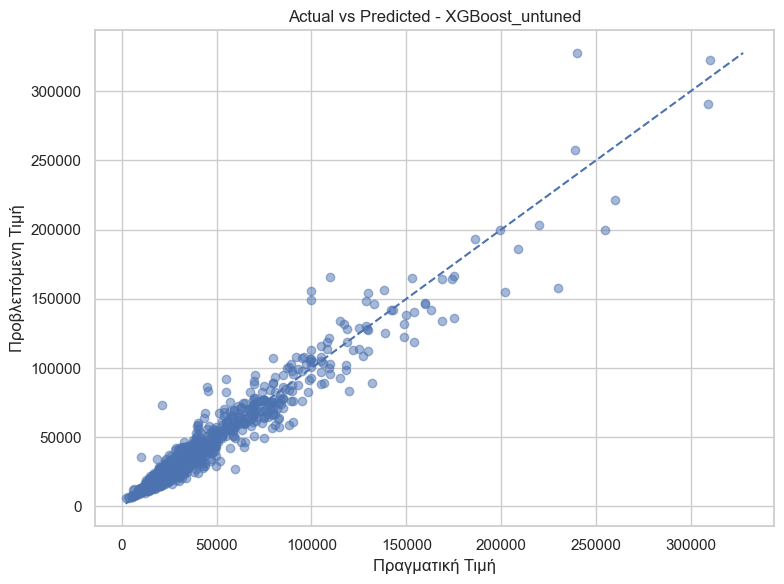

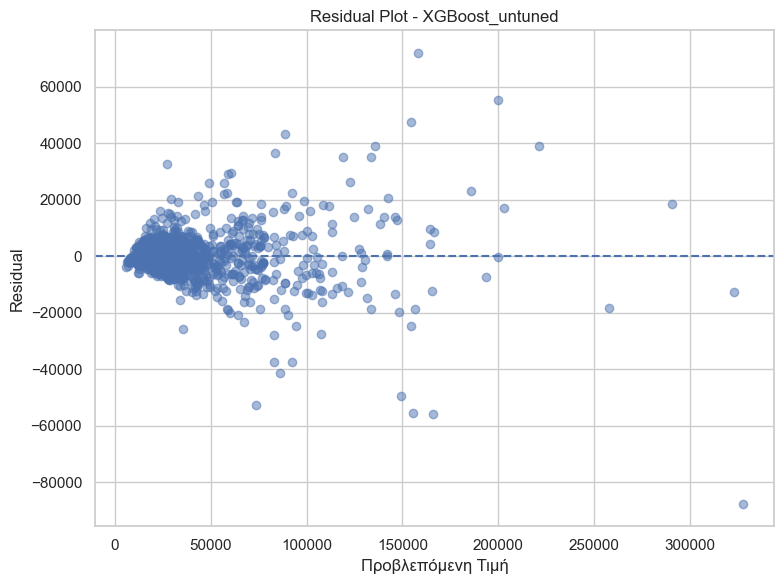

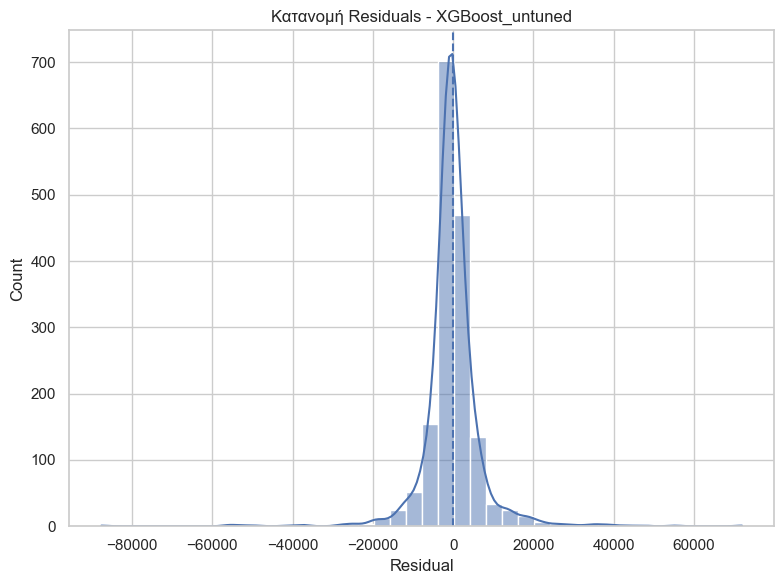

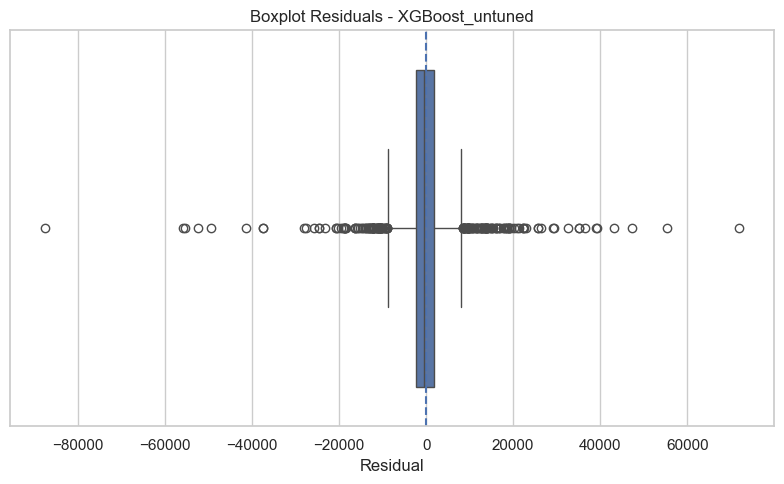

In [13]:
# ============================================================
# DIAGNOSTIC PLOTS: ACTUAL VS PREDICTED / RESIDUALS
# ============================================================

# ----------------------------------------
# 1. Actual vs Predicted
# ----------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(
    final_predictions_df["Actual_Price"],
    final_predictions_df["Predicted_Price"],
    alpha=0.50
)

min_val = min(final_predictions_df["Actual_Price"].min(), final_predictions_df["Predicted_Price"].min())
max_val = max(final_predictions_df["Actual_Price"].max(), final_predictions_df["Predicted_Price"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Πραγματική Τιμή")
plt.ylabel("Προβλεπόμενη Τιμή")
plt.title(f"Actual vs Predicted - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. Residuals vs Predicted
# ----------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(
    final_predictions_df["Predicted_Price"],
    final_predictions_df["Residual"],
    alpha=0.50
)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Προβλεπόμενη Τιμή")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 3. Κατανομή residuals
# ----------------------------------------
plt.figure(figsize=(8, 6))
sns.histplot(final_predictions_df["Residual"], bins=40, kde=True)
plt.axvline(x=0, linestyle="--")
plt.xlabel("Residual")
plt.title(f"Κατανομή Residuals - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 4. Boxplot residuals
# ----------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x=final_predictions_df["Residual"])
plt.axvline(x=0, linestyle="--")
plt.xlabel("Residual")
plt.title(f"Boxplot Residuals - {final_model_name}")
plt.tight_layout()
plt.show()

## Ανάλυση Σφάλματος ανά Βασικές Ομάδες

Για πιο ουσιαστική κατανόηση της απόδοσης του μοντέλου, το prediction error εξετάζεται ανά:

- **fuel type**
- **manufacturer**
- **registration year**
- **price segment**

Η ανάλυση αυτή είναι ιδιαίτερα χρήσιμη, διότι επιτρέπει να εντοπιστούν:

- τμήματα της αγοράς στα οποία το μοντέλο λειτουργεί καλύτερα
- ομάδες στις οποίες το σφάλμα αυξάνεται
- και πιθανά πεδία για μελλοντική βελτίωση του modeling pipeline

In [14]:
# ============================================================
# ERROR ANALYSIS BY FUEL / MAKE / YEAR / PRICE SEGMENT
# ============================================================

# Fuel type
error_by_fuel_df = metrics_by_group(
    final_predictions_df,
    group_col="Καύσιμο",
    min_count=20
).sort_values(by="RMSE", ascending=False).reset_index(drop=True)

# Make:
# Κρατάμε κυρίως κατασκευαστές με επαρκές πλήθος παρατηρήσεων για σταθερότερη ερμηνεία
make_counts = final_predictions_df["Κατασκευαστής"].value_counts()
eligible_makes = make_counts[make_counts >= 25].index.tolist()

error_by_make_df = metrics_by_group(
    final_predictions_df[final_predictions_df["Κατασκευαστής"].isin(eligible_makes)].copy(),
    group_col="Κατασκευαστής",
    min_count=25
).sort_values(by="RMSE", ascending=False).reset_index(drop=True)

# Registration year
error_by_year_df = metrics_by_group(
    final_predictions_df,
    group_col="Εγγραφή",
    min_count=20
).sort_values(by="Εγγραφή").reset_index(drop=True)

# Price segment
error_by_price_segment_df = metrics_by_group(
    final_predictions_df,
    group_col="Price_Segment",
    min_count=20
).reset_index(drop=True)

print("Error by fuel type:")
display(error_by_fuel_df)

print("\nError by make (μόνο make με τουλάχιστον 25 παρατηρήσεις στο test set):")
display(error_by_make_df)

print("\nError by registration year:")
display(error_by_year_df)

print("\nError by price segment:")
display(error_by_price_segment_df)

Error by fuel type:


,Καύσιμο,Count,Mean_Actual_Price,Mean_Predicted_Price,MAE,RMSE,R2,MedAE,Bias,MAPE_%
0,Plug-in Hybrid Πετρελαίου,49,"70,832.16","70,854.26","6,665.06","9,168.58",0.76,"4,396.54",-22.09,9.15
1,Βενζίνη,574,"28,678.17","29,027.53","3,356.46","8,318.35",0.95,"1,537.54",-349.37,10.59
2,Ηλεκτρικό,129,"36,557.71","36,664.86","5,659.81","8,259.20",0.88,"3,363.73",-107.16,17.17
3,Plug-in Hybrid Βενζίνης,212,"49,529.42","50,242.33","5,650.83","8,047.42",0.94,"3,946.05",-712.91,11.73
4,Υβριδικό Πετρελαίου,48,"58,634.96","59,514.23","5,636.33","7,783.27",0.88,"3,748.24",-879.27,9.88
5,Πετρέλαιο,345,"26,053.00","25,767.78","3,870.46","7,167.66",0.89,"1,937.18",285.22,15.59
6,Υβριδικό Βενζίνης,289,"27,206.44","27,252.07","3,362.58","5,412.25",0.95,"1,978.86",-45.63,11.55



Error by make (μόνο make με τουλάχιστον 25 παρατηρήσεις στο test set):


,Κατασκευαστής,Count,Mean_Actual_Price,Mean_Predicted_Price,MAE,RMSE,R2,MedAE,Bias,MAPE_%
0,Porsche,31,"125,236.77","125,667.65","14,501.58","23,340.76",0.87,"8,629.34",-430.87,10.05
1,BMW,135,"56,582.82","56,016.59","7,064.45","11,820.03",0.92,"4,258.36",566.23,12.34
2,Mercedes-Benz,195,"58,151.44","57,534.00","7,270.66","11,026.41",0.89,"4,767.18",617.44,13.71
3,LandRover,47,"70,375.30","69,204.16","8,282.01","10,615.58",0.90,"6,212.98","1,171.15",16.39
4,Audi,61,"49,123.61","48,558.75","5,503.18","8,834.20",0.94,"2,938.68",564.85,10.26
5,Volkswagen,88,"23,702.76","23,531.98","4,279.69","7,416.56",0.33,"2,221.91",170.78,16.68
6,Ford,84,"24,296.87","25,740.07","3,430.55","6,833.81",0.72,"1,499.25","-1,443.20",12.02
7,Volvo,28,"33,996.79","35,252.10","3,524.08","5,544.65",0.60,"2,157.74","-1,255.31",10.52
8,Jeep,45,"30,912.22","31,119.68","3,678.30","5,503.07",0.94,"2,390.60",-207.46,11.03
9,MG,28,"20,413.93","21,731.19","3,377.28","4,258.97",0.27,"3,315.08","-1,317.26",16.14



Error by registration year:


,Εγγραφή,Count,Mean_Actual_Price,Mean_Predicted_Price,MAE,RMSE,R2,MedAE,Bias,MAPE_%
0,2021,616,"27,753.34","28,117.44","3,319.42","6,444.77",0.94,"1,924.12",-364.10,11.69
1,2022,476,"32,792.22","33,061.70","3,960.18","7,129.69",0.95,"2,145.58",-269.48,12.46
2,2023,262,"38,001.67","38,141.31","5,464.03","9,862.81",0.91,"3,135.80",-139.64,14.72
3,2024,155,"48,825.51","47,866.28","5,769.64","9,430.18",0.95,"3,487.55",959.23,13.68
4,2025,151,"31,862.01","32,387.73","3,530.79","6,565.21",0.96,"1,659.45",-525.73,9.96



Error by price segment:


,Price_Segment,Count,Mean_Actual_Price,Mean_Predicted_Price,MAE,RMSE,R2,MedAE,Bias,MAPE_%
0,10k–20k,667,"15,910.00","16,702.91","1,625.66","2,230.39",0.32,"1,239.19",-792.91,10.25
1,20k–35k,533,"25,988.65","26,213.81","3,239.85","4,680.25",-0.27,"2,429.43",-225.16,12.41
2,35k–60k,218,"45,009.66","45,609.23","6,554.21","9,213.14",-0.83,"4,850.83",-599.57,14.57
3,<=10k,39,"7,992.05","10,944.45","2,981.02","4,900.48",-4.63,"2,292.04","-2,952.40",41.77
4,>60k,203,"100,753.67","97,921.71","11,983.25","17,352.62",0.85,"8,490.10","2,831.94",11.63


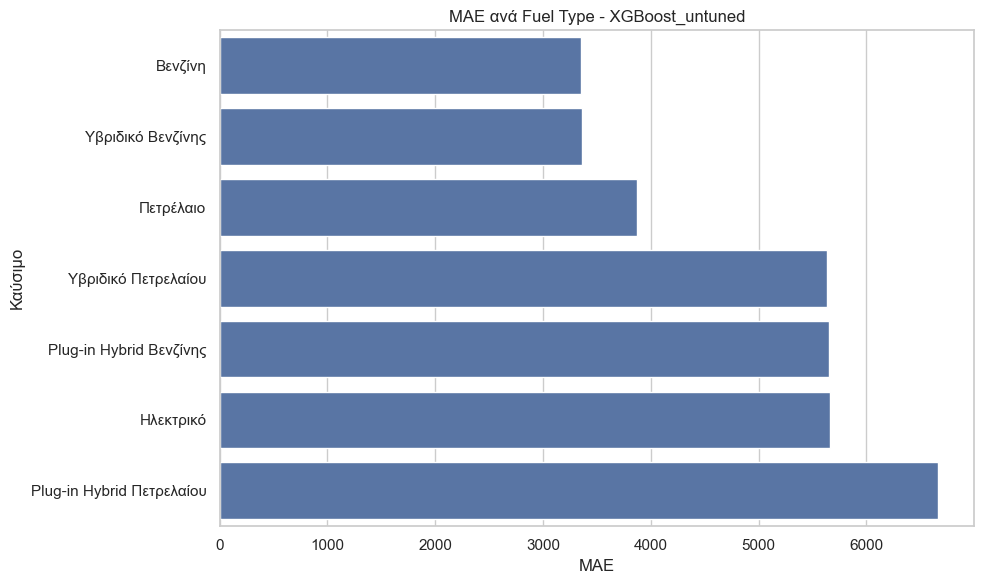

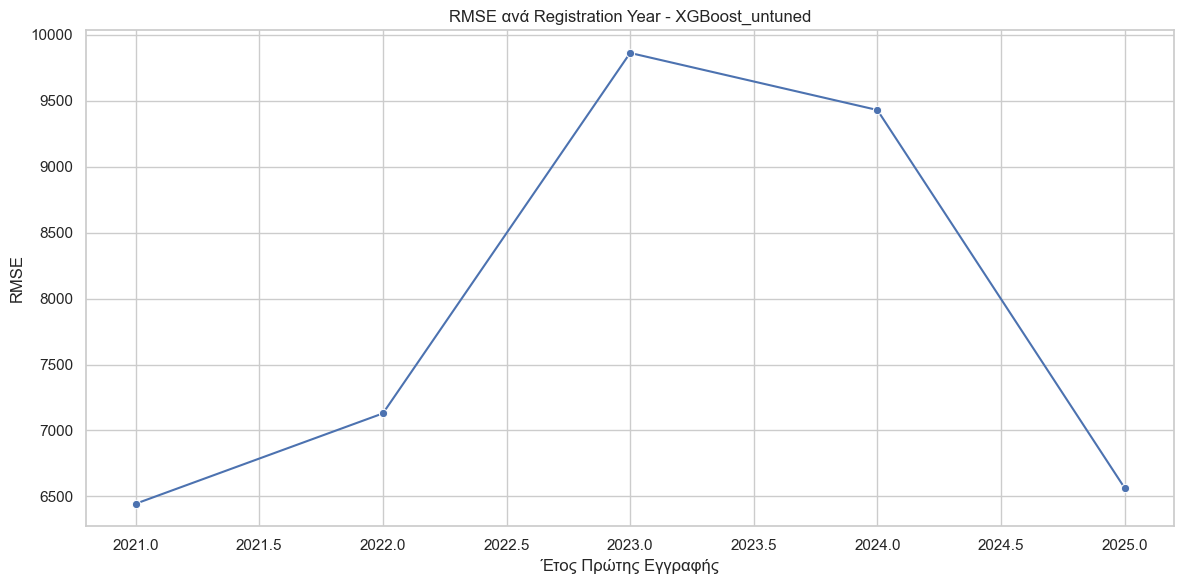

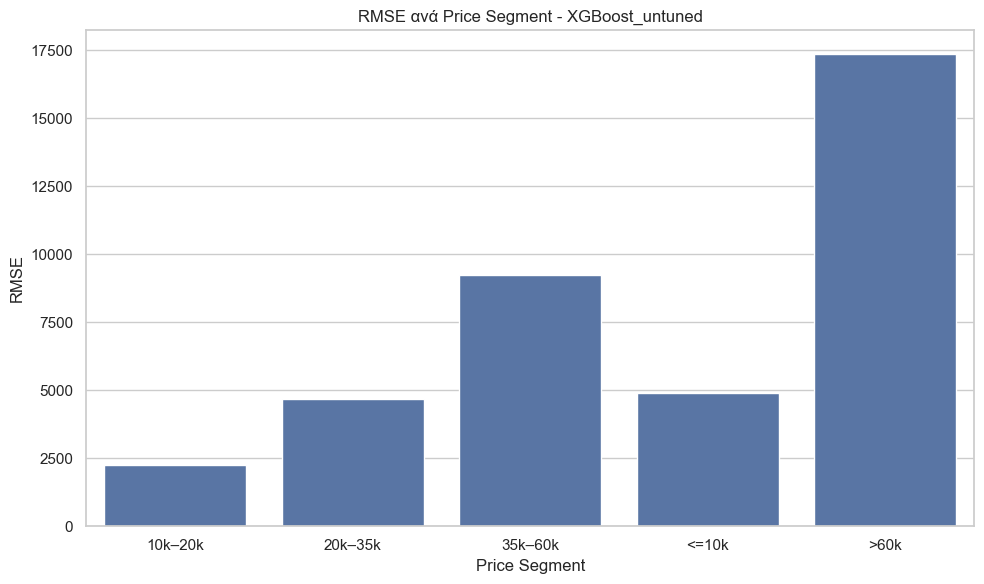

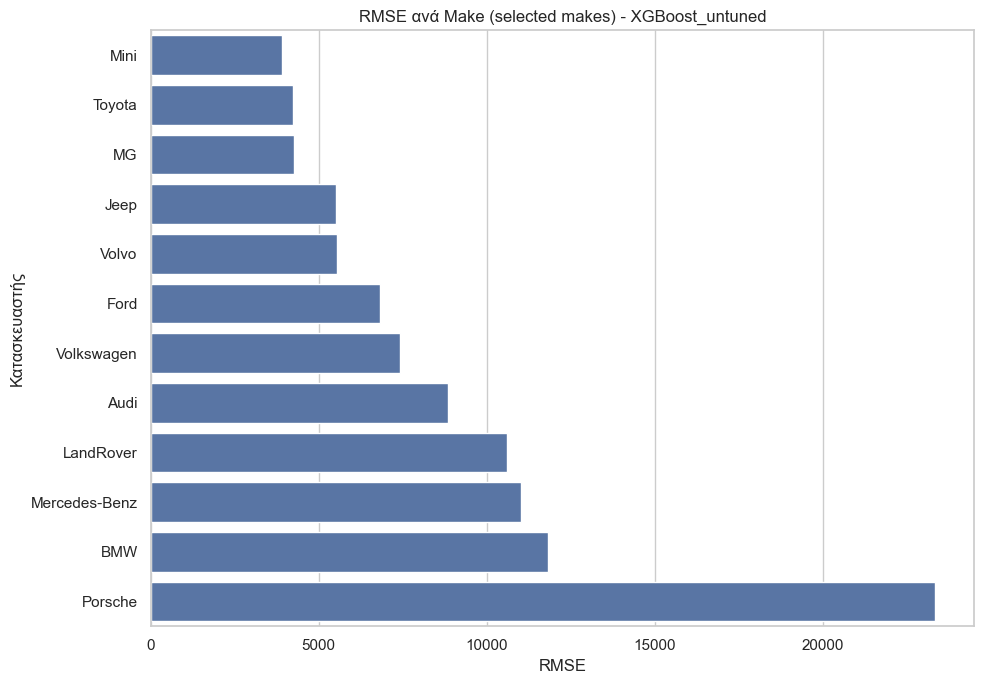

In [15]:
# ============================================================
# VISUALIZATIONS ΓΙΑ ΟΜΑΔΟΠΟΙΗΜΕΝΗ ΑΝΑΛΥΣΗ ΣΦΑΛΜΑΤΟΣ
# ============================================================

# ----------------------------------------
# 1. MAE ανά fuel type
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    data=error_by_fuel_df.sort_values(by="MAE", ascending=True),
    x="MAE",
    y="Καύσιμο"
)
plt.xlabel("MAE")
plt.ylabel("Καύσιμο")
plt.title(f"MAE ανά Fuel Type - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. RMSE ανά registration year
# ----------------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=error_by_year_df,
    x="Εγγραφή",
    y="RMSE",
    marker="o"
)
plt.xlabel("Έτος Πρώτης Εγγραφής")
plt.ylabel("RMSE")
plt.title(f"RMSE ανά Registration Year - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 3. RMSE ανά price segment
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    data=error_by_price_segment_df,
    x="Price_Segment",
    y="RMSE"
)
plt.xlabel("Price Segment")
plt.ylabel("RMSE")
plt.title(f"RMSE ανά Price Segment - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 4. Top makes ως προς RMSE
# ----------------------------------------
top_make_plot_df = error_by_make_df.head(12).sort_values(by="RMSE", ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_make_plot_df,
    x="RMSE",
    y="Κατασκευαστής"
)
plt.xlabel("RMSE")
plt.ylabel("Κατασκευαστής")
plt.title(f"RMSE ανά Make (selected makes) - {final_model_name}")
plt.tight_layout()
plt.show()

## Residual Behavior ανά Market Segment

Πέρα από τις συγκεντρωτικές μετρικές, παρουσιάζεται και η συμπεριφορά των residuals σε επιλεγμένα segments της αγοράς.

Η προσέγγιση αυτή επιτρέπει να εντοπιστεί εάν το μοντέλο:

- τείνει να **υποεκτιμά** συστηματικά ακριβότερα οχήματα
- εμφανίζει **μεγαλύτερη διασπορά** σε συγκεκριμένα fuel types
- ή διατηρεί **συμμετρικότερη** συμπεριφορά σε ορισμένες κατηγορίες

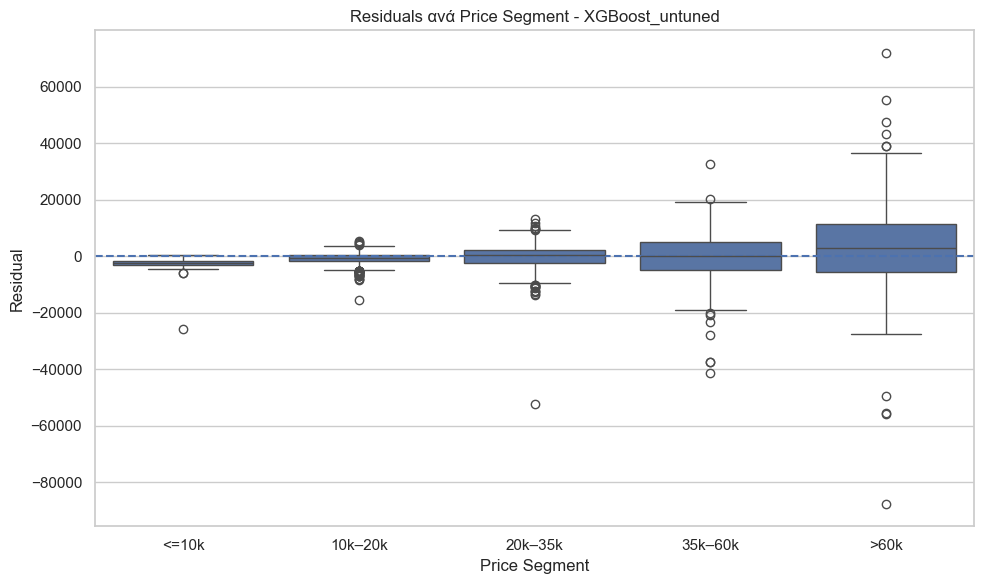

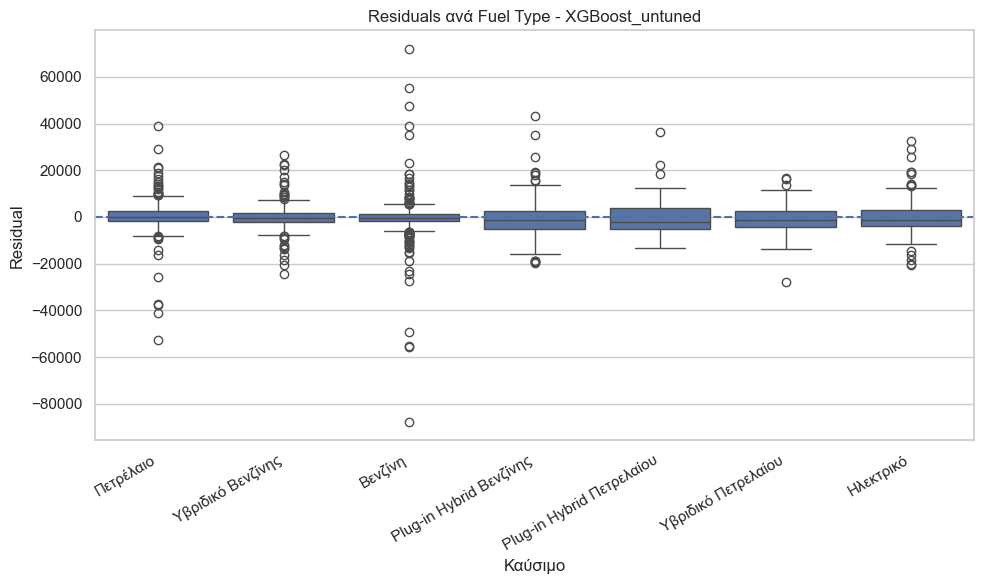

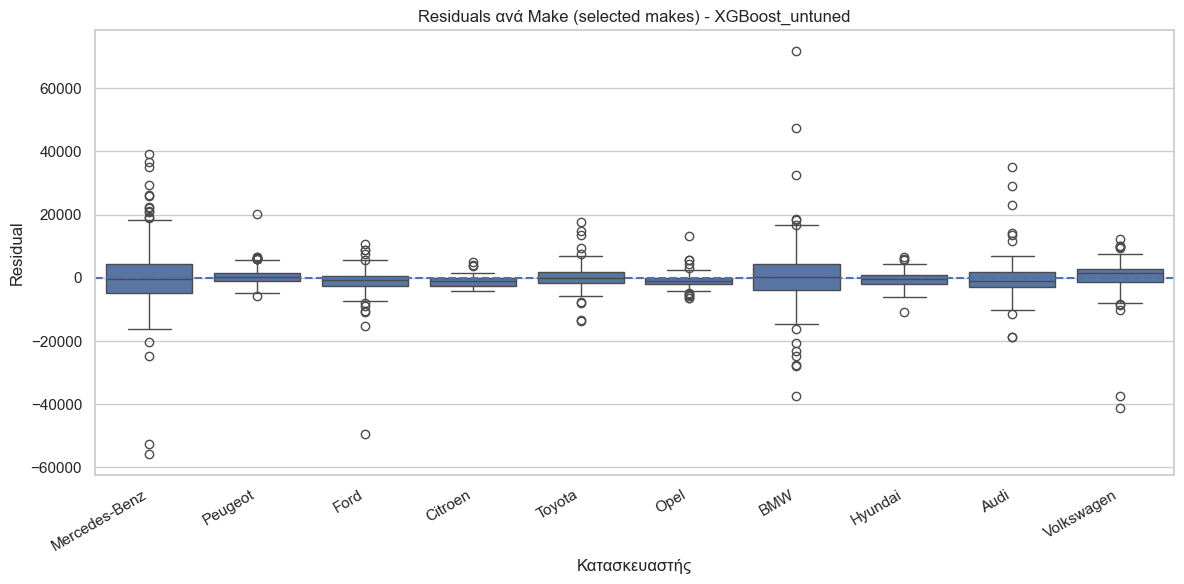

In [16]:
# ============================================================
# RESIDUAL BEHAVIOR BY SEGMENT
# ============================================================

# ----------------------------------------
# 1. Residuals ανά price segment
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=final_predictions_df,
    x="Price_Segment",
    y="Residual"
)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Price Segment")
plt.ylabel("Residual")
plt.title(f"Residuals ανά Price Segment - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. Residuals ανά fuel type
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=final_predictions_df[final_predictions_df["Καύσιμο"].isin(error_by_fuel_df["Καύσιμο"])],
    x="Καύσιμο",
    y="Residual"
)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Καύσιμο")
plt.ylabel("Residual")
plt.title(f"Residuals ανά Fuel Type - {final_model_name}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 3. Residuals για επιλεγμένους makes
# ----------------------------------------
top_residual_makes = eligible_makes[:10]
residual_make_plot_df = final_predictions_df[
    final_predictions_df["Κατασκευαστής"].isin(top_residual_makes)
].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=residual_make_plot_df,
    x="Κατασκευαστής",
    y="Residual"
)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Κατασκευαστής")
plt.ylabel("Residual")
plt.title(f"Residuals ανά Make (selected makes) - {final_model_name}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## SHAP Interpretability για το Τελικό Μοντέλο

Για την ερμηνεία του τελικού μοντέλου εφαρμόζεται η μέθοδος **SHAP (SHapley Additive exPlanations)**.

Η συγκεκριμένη τεχνική επιτρέπει:

- τον υπολογισμό της συνεισφοράς κάθε μεταβλητής σε κάθε πρόβλεψη
- την ανάδειξη των σημαντικότερων παραγόντων διαμόρφωσης της τιμής
- και τη σύνδεση της αλγοριθμικής πρόβλεψης με οικονομικά και τεχνικά χαρακτηριστικά του οχήματος

Επειδή το preprocessing περιλαμβάνει one-hot encoding, παρουσιάζονται δύο επίπεδα ερμηνείας:

1. **transformed features** μετά το pipeline  
2. **grouped SHAP importance** σε επίπεδο αρχικών μεταβλητών

In [17]:
# ============================================================
# ΥΠΟΛΟΓΙΣΜΟΣ SHAP VALUES
# ============================================================

final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_model = final_pipeline.named_steps["model"]

feature_names_transformed = final_preprocessor.get_feature_names_out()

# Sample για ταχύτερη και πιο ελεγχόμενη ερμηνεία
shap_n = min(SHAP_SAMPLE_SIZE, len(X_test))
X_shap = X_test.sample(n=shap_n, random_state=RANDOM_STATE).copy()

X_shap_transformed = final_preprocessor.transform(X_shap)

# Προστασία σε περίπτωση sparse matrix
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names_transformed,
    index=X_shap.index
)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap_df)

# Συμβατότητα με διαφορετικές μορφές εξόδου του SHAP
if isinstance(shap_values, list):
    shap_values = shap_values[0]

if hasattr(shap_values, "values"):
    shap_values = shap_values.values

transformed_shap_importance_df = pd.DataFrame({
    "Transformed_Feature": feature_names_transformed,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(by="Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

grouped_shap_importance_df = transformed_shap_importance_df.copy()
grouped_shap_importance_df["Feature_Group"] = grouped_shap_importance_df["Transformed_Feature"].apply(
    lambda x: get_original_feature_name(x, numeric_features, categorical_features)
)

grouped_shap_importance_df = (
    grouped_shap_importance_df
    .groupby("Feature_Group", as_index=False)["Mean_Abs_SHAP"]
    .sum()
    .sort_values(by="Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

print("Top transformed SHAP features:")
display(transformed_shap_importance_df.head(20))

print("\nGrouped SHAP importance ανά αρχική μεταβλητή:")
display(grouped_shap_importance_df)

Top transformed SHAP features:


,Transformed_Feature,Mean_Abs_SHAP
0,num__Ιπποδύναμη,"10,166.43"
1,num__Κυβικά,"8,347.48"
2,num__Χιλιόμετρα,"2,495.50"
3,cat__Κατασκευαστής_Mercedes-Benz,"1,570.98"
4,num__Ηλικία,"1,495.47"
5,cat__Κατασκευαστής_Porsche,567.34
6,cat__Μετάδοση_Χειροκίνητο,537.71
7,cat__Καύσιμο_Πετρέλαιο,438.85
8,cat__Μετάδοση_Αυτόματο,422.89
9,cat__Κατασκευαστής_LandRover,400.09



Grouped SHAP importance ανά αρχική μεταβλητή:


,Feature_Group,Mean_Abs_SHAP
0,Ιπποδύναμη,"10,166.43"
1,Κυβικά,"8,347.48"
2,Κατασκευαστής,"3,648.93"
3,Χιλιόμετρα,"2,495.50"
4,Τύπος,"1,535.61"
5,Ηλικία,"1,495.47"
6,Καύσιμο,"1,270.56"
7,Μετάδοση,960.79
8,Περιοχή,583.43


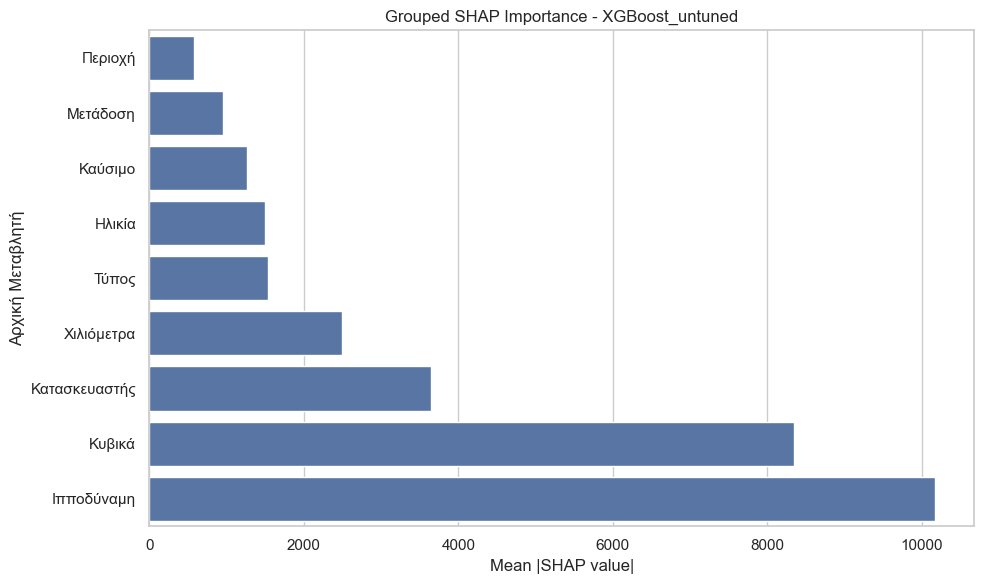

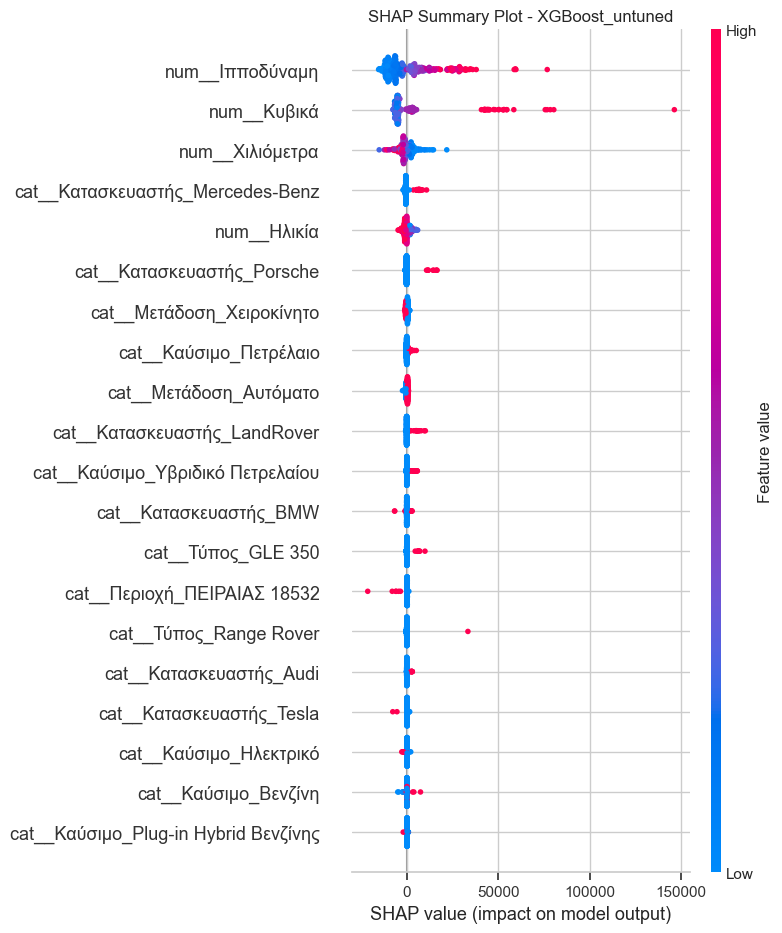

In [18]:
# ============================================================
# SHAP PLOTS
# ============================================================

# ----------------------------------------
# 1. Grouped SHAP importance
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped_shap_importance_df.sort_values(by="Mean_Abs_SHAP", ascending=True),
    x="Mean_Abs_SHAP",
    y="Feature_Group"
)
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Αρχική Μεταβλητή")
plt.title(f"Grouped SHAP Importance - {final_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. SHAP summary plot (transformed features)
# ----------------------------------------
shap.summary_plot(
    shap_values,
    X_shap_df,
    max_display=20,
    show=False
)
plt.title(f"SHAP Summary Plot - {final_model_name}")
plt.tight_layout()
plt.show()

## Εξαγωγή Αποτελεσμάτων του Notebook 3

Για λόγους τεκμηρίωσης και αναπαραγωγιμότητας, αποθηκεύονται:

- τα συνολικά αποτελέσματα tuning
- οι test-set μετρικές όλων των υποψήφιων εκδοχών
- η σύγκριση tuned vs untuned
- ο αναλυτικός πίνακας τελικών προβλέψεων
- τα grouped error tables
- και οι πίνακες SHAP importance

Τα αρχεία αυτά μπορούν να αξιοποιηθούν τόσο στο επόμενο στάδιο συγγραφής της πτυχιακής όσο και σε πίνακες, παραρτήματα ή παρουσίαση αποτελεσμάτων.

In [19]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================

output_dir = resolve_output_dir()

files_to_export = {
    "notebook3_search_summary.csv": search_summary_df,
    "notebook3_model_test_results.csv": evaluation_df,
    "notebook3_tuned_vs_untuned_comparison.csv": tuned_vs_untuned_df,
    "notebook3_final_model_predictions.csv": final_predictions_df.reset_index(drop=True),
    "notebook3_error_by_fuel_type.csv": error_by_fuel_df,
    "notebook3_error_by_make.csv": error_by_make_df,
    "notebook3_error_by_registration_year.csv": error_by_year_df,
    "notebook3_error_by_price_segment.csv": error_by_price_segment_df,
    "notebook3_transformed_shap_importance.csv": transformed_shap_importance_df,
    "notebook3_grouped_shap_importance.csv": grouped_shap_importance_df,
}

for filename, export_df in files_to_export.items():
    export_path = output_dir / filename
    export_df.to_csv(export_path, index=False, encoding="utf-8-sig")

print("Αποθηκεύτηκαν τα εξής αρχεία:")
for filename in files_to_export:
    print("-", output_dir / filename)

Αποθηκεύτηκαν τα εξής αρχεία:
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_search_summary.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_model_test_results.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_tuned_vs_untuned_comparison.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_final_model_predictions.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_error_by_fuel_type.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_error_by_make.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_error_by_registration_year.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_error_by_price_segment.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook3_transformed_shap_importance.csv
- c:\Users\athin\Desktop\Car-Market-Analysis

## Συμπεράσματα του Notebook 3

Στο τελικό αυτό στάδιο συνοψίζονται τα βασικά ευρήματα της ανάλυσης:

- η επίδραση του hyperparameter tuning
- η συγκριτική θέση των RandomForest και XGBoost
- η συμπεριφορά του τελικού μοντέλου σε διαφορετικά segments της αγοράς
- και η ερμηνεία των αποτελεσμάτων μέσω SHAP

Το παρακάτω κελί δημιουργεί μια δυναμική σύνοψη, βασισμένη στα πραγματικά αποτελέσματα που παρήχθησαν στο notebook.

In [20]:
# ============================================================
# ΔΥΝΑΜΙΚΗ ΤΕΛΙΚΗ ΣΥΝΟΨΗ
# ============================================================

best_overall_row = evaluation_df.iloc[0]

xgb_best_row = evaluation_df[evaluation_df["Model_Family"] == "XGBoost"].sort_values(by="RMSE").iloc[0]
rf_best_row = evaluation_df[evaluation_df["Model_Family"] == "RandomForest"].sort_values(by="RMSE").iloc[0]

best_family = best_overall_row["Model_Family"]
best_status = best_overall_row["Tuning_Status"]

best_family_tuning_row = tuned_vs_untuned_df[tuned_vs_untuned_df["Model_Family"] == best_family].iloc[0]
best_family_rmse_improvement = best_family_tuning_row["RMSE_Improvement_%"]
best_family_mae_improvement = best_family_tuning_row["MAE_Improvement_%"]

if best_family_rmse_improvement > 0:
    tuning_sentence = (
        f"Για την οικογένεια μοντέλων {best_family}, το tuning βελτίωσε το RMSE κατά "
        f"{best_family_rmse_improvement:.2f}% και το MAE κατά {best_family_mae_improvement:.2f}%."
    )
else:
    tuning_sentence = (
        f"Για την οικογένεια μοντέλων {best_family}, το tuning δεν οδήγησε σε ουσιαστική βελτίωση "
        f"στο test set, καθώς η μεταβολή του RMSE ήταν {best_family_rmse_improvement:.2f}%."
    )

if xgb_best_row["RMSE"] < rf_best_row["RMSE"]:
    family_comparison_sentence = (
        f"Σε επίπεδο model family, η καλύτερη εκδοχή του XGBoost υπερείχε της καλύτερης εκδοχής "
        f"του RandomForest κατά {rf_best_row['RMSE'] - xgb_best_row['RMSE']:.2f} μονάδες RMSE."
    )
else:
    family_comparison_sentence = (
        f"Σε επίπεδο model family, η καλύτερη εκδοχή του RandomForest υπερείχε της καλύτερης εκδοχής "
        f"του XGBoost κατά {xgb_best_row['RMSE'] - rf_best_row['RMSE']:.2f} μονάδες RMSE."
    )

conclusion_text = f"""
ΣΥΝΟΠΤΙΚΟ ΣΥΜΠΕΡΑΣΜΑ NOTEBOOK 3
--------------------------------
1. Το τελικό επιλεγμένο μοντέλο είναι το: {best_overall_row['Model']}.

2. Η τελική του απόδοση στο test set είναι:
   - MAE  = {best_overall_row['MAE']:.2f}
   - RMSE = {best_overall_row['RMSE']:.2f}
   - R²   = {best_overall_row['R2']:.4f}
   - MedAE = {best_overall_row['MedAE']:.2f}
   - Bias = {best_overall_row['Bias']:.2f}

3. Το μοντέλο αυτό ανήκει στην οικογένεια {best_family} και είναι η εκδοχή:
   {best_status}.

4. {tuning_sentence}

5. {family_comparison_sentence}

6. Το αναλυτικό error analysis και η residual analysis επιτρέπουν την αξιολόγηση
   της σταθερότητας του μοντέλου σε διαφορετικά τμήματα της αγοράς, ενώ η SHAP
   ερμηνεία αναδεικνύει τις μεταβλητές που επηρεάζουν περισσότερο την τελική πρόβλεψη.

7. Συνεπώς, το συγκεκριμένο μοντέλο μπορεί να τεκμηριωθεί ως η τελική επιλογή
   για παρουσίαση στην πτυχιακή εργασία, υπό την προϋπόθεση ότι τα διαγνωστικά
   σφάλματος και οι ομαδοποιημένες αναλύσεις κρίνονται ικανοποιητικά.
"""

print(conclusion_text)


ΣΥΝΟΠΤΙΚΟ ΣΥΜΠΕΡΑΣΜΑ NOTEBOOK 3
--------------------------------
1. Το τελικό επιλεγμένο μοντέλο είναι το: XGBoost_untuned.

2. Η τελική του απόδοση στο test set είναι:
   - MAE  = 4089.66
   - RMSE = 7587.25
   - R²   = 0.9417
   - MedAE = 2163.86
   - Bias = -192.68

3. Το μοντέλο αυτό ανήκει στην οικογένεια XGBoost και είναι η εκδοχή:
   Untuned.

4. Για την οικογένεια μοντέλων XGBoost, το tuning δεν οδήγησε σε ουσιαστική βελτίωση στο test set, καθώς η μεταβολή του RMSE ήταν -1.49%.

5. Σε επίπεδο model family, η καλύτερη εκδοχή του XGBoost υπερείχε της καλύτερης εκδοχής του RandomForest κατά 572.61 μονάδες RMSE.

6. Το αναλυτικό error analysis και η residual analysis επιτρέπουν την αξιολόγηση
   της σταθερότητας του μοντέλου σε διαφορετικά τμήματα της αγοράς, ενώ η SHAP
   ερμηνεία αναδεικνύει τις μεταβλητές που επηρεάζουν περισσότερο την τελική πρόβλεψη.

7. Συνεπώς, το συγκεκριμένο μοντέλο μπορεί να τεκμηριωθεί ως η τελική επιλογή
   για παρουσίαση στην πτυχιακή εργασία, υπό την